<a href="https://colab.research.google.com/github/intanintanauliazalzabila-create/prediksi_konsumsi_energi/blob/main/prediksi_konsumsi_energi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pemanfaatan Decision Tree dan Random Forest untuk Memprediksi Konsumsi Energi Rumah Tangga sebagai Upaya Penghematan Energi

**Mata Kuliah:** Kecerdasan Buatan  
**Kaitan:** SDG 7 – Affordable and Clean Energy

Notebook ini digunakan untuk mengklasifikasikan tingkat konsumsi energi rumah tangga menjadi tiga kategori, yaitu Rendah, Sedang, dan Tinggi menggunakan algoritma Decision Tree dan Random Forest.

##1. Memuat Dataset

Dataset yang digunakan adalah **Household Power Consumption** yang diperoleh dari Kaggle.

Dataset berisi informasi mengenai penggunaan energi listrik rumah tangga.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption - Copy.csv to household_power_consumption - Copy.csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("household_power_consumption - Copy.csv")

##2. Melihat Kondisi Awal Data

Pada tahap ini dilakukan pemeriksaan jumlah data, tipe data, nilai kosong, dan data duplikat.

In [ ]:
df.head()

,time,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
0,00:00:00,2.580,0.136,241.97,10.6,0.0,0.0,0.0
1,00:01:00,2.552,0.100,241.75,10.4,0.0,0.0,0.0
2,00:02:00,2.550,0.100,241.64,10.4,0.0,0.0,0.0
3,00:03:00,2.550,0.100,241.71,10.4,0.0,0.0,0.0
4,00:04:00,2.554,0.100,241.98,10.4,0.0,0.0,0.0


### Informasi Struktur Data

Pada tahap ini dilakukan pemeriksaan struktur dataset untuk mengetahui jumlah data, nama kolom, tipe data, dan jumlah data yang tersedia pada setiap kolom.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   time                   260640 non-null  object 
 1   global_active_power    256869 non-null  float64
 2   global_reactive_power  256869 non-null  float64
 3   voltage                256869 non-null  float64
 4   global_intensity       256869 non-null  float64
 5   sub_metering_1         256869 non-null  float64
 6   sub_metering_2         256869 non-null  float64
 7   sub_metering_3         256869 non-null  float64
dtypes: float64(7), object(1)
memory usage: 15.9+ MB


In [ ]:
df.shape

(260640, 8)

## 3. Preprocessing Data

Tahap preprocessing dilakukan untuk membersihkan data sebelum digunakan dalam proses machine learning.

Proses yang dilakukan:
- Menghapus data duplikat.
- Menghapus data yang memiliki nilai kosong.
- Mengubah format kolom waktu.

### Pemeriksaan Nilai Kosong

Pada tahap ini dilakukan pemeriksaan untuk mengetahui jumlah nilai kosong (missing value) pada setiap kolom dalam dataset.

In [ ]:
df.isnull().sum()

,0
time,0
global_active_power,3771
global_reactive_power,3771
voltage,3771
global_intensity,3771
sub_metering_1,3771
sub_metering_2,3771
sub_metering_3,3771


In [ ]:
df.duplicated().sum()

np.int64(2356)

### Pemeriksaan Data Duplikat

Pada tahap ini dilakukan pemeriksaan untuk mengetahui apakah terdapat baris data yang memiliki isi yang sama (duplikat).

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Menghapus data yang memiliki nilai kosong
df = df.dropna()

# Melihat ukuran data setelah dibersihkan
df.shape

(256844, 8)

In [ ]:
# Mengecek kembali data kosong
df.isnull().sum()

,0
time,0
global_active_power,0
global_reactive_power,0
voltage,0
global_intensity,0
sub_metering_1,0
sub_metering_2,0
sub_metering_3,0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Ringkasan Statistik Data

Pada tahap ini digunakan `df.describe()` untuk melihat ringkasan statistik dari kolom numerik, seperti nilai minimum, maksimum, rata-rata, dan kuartil.

In [ ]:
df.describe()

,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
count,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000,256844.000000
mean,1.165029,0.123740,239.208773,4.975153,1.332610,1.670773,5.832392
std,1.181853,0.111871,3.592846,4.999574,6.705284,6.631664,8.186905
min,0.082000,0.000000,223.490000,0.400000,0.000000,0.000000,0.000000
25%,0.296000,0.000000,236.650000,1.400000,0.000000,0.000000,0.000000
50%,0.564000,0.104000,239.610000,2.600000,0.000000,0.000000,0.000000
75%,1.606000,0.194000,241.810000,6.800000,0.000000,1.000000,17.000000
max,10.670000,1.148000,250.890000,46.400000,78.000000,78.000000,20.000000


### Pemeriksaan Kolom Waktu

Pada tahap ini dilakukan pemeriksaan terhadap kolom `time` untuk melihat format data waktu sebelum dilakukan perubahan tipe data.

In [ ]:
df['time'].head(10)

,time
0,00:00:00
1,00:01:00
2,00:02:00
3,00:03:00
4,00:04:00
5,00:05:00
6,00:06:00
7,00:07:00
8,00:08:00
9,00:09:00


### Mengubah Format Kolom Waktu

Kolom `time` diubah dari tipe data teks menjadi tipe data datetime agar dapat diproses dengan lebih mudah dalam Python.

In [ ]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

df['time'].head()

,time
0,1900-01-01 00:00:00
1,1900-01-01 00:01:00
2,1900-01-01 00:02:00
3,1900-01-01 00:03:00
4,1900-01-01 00:04:00


## 4. Pembentukan Kategori Konsumsi Energi

Kolom `global_active_power` digunakan untuk membentuk target klasifikasi menjadi tiga kategori:

- Rendah: ≤ 0,296
- Sedang: > 0,296 sampai 1,606
- Tinggi: > 1,606

In [ ]:
# Membuat kategori konsumsi energi

df['energy_category'] = pd.cut(
    df['global_active_power'],
    bins=[0, 0.296, 1.606, float('inf')],
    labels=['Rendah', 'Sedang', 'Tinggi']
)

# Melihat hasil kategori
df[['global_active_power', 'energy_category']].head(10)

,global_active_power,energy_category
0,2.580,Tinggi
1,2.552,Tinggi
2,2.550,Tinggi
3,2.550,Tinggi
4,2.554,Tinggi
5,2.550,Tinggi
6,2.534,Tinggi
7,2.484,Tinggi
8,2.468,Tinggi
9,2.486,Tinggi


### Jumlah Data Setiap Kategori

Kode berikut digunakan untuk mengetahui jumlah data pada kategori Rendah, Sedang, dan Tinggi.

In [ ]:
df['energy_category'].value_counts()

,count
energy_category,
Sedang,128118
Rendah,64575
Tinggi,64151


## 5. Menentukan Fitur dan Target

Pada tahap ini ditentukan data yang digunakan sebagai input model (fitur) dan data yang menjadi hasil yang akan diprediksi (target).

Fitur yang digunakan:
- `global_reactive_power`
- `voltage`
- `global_intensity`
- `sub_metering_1`
- `sub_metering_2`
- `sub_metering_3`

Target yang diprediksi adalah `energy_category`, yaitu kategori konsumsi energi Rendah, Sedang, dan Tinggi.

Kolom `global_active_power` tidak digunakan sebagai fitur karena kolom tersebut digunakan untuk membentuk target `energy_category`.

In [ ]:
X = df[
    [
        'global_reactive_power',
        'voltage',
        'global_intensity',
        'sub_metering_1',
        'sub_metering_2',
        'sub_metering_3'
    ]
]

y = df['energy_category']

print("Jumlah data X:", X.shape)
print("Jumlah data y:", y.shape)

Jumlah data X: (256844, 6)
Jumlah data y: (256844,)


## 6. Pembagian Data Training dan Testing

Data dibagi menjadi dua bagian, yaitu data training dan data testing.

- 80% data digunakan untuk training atau melatih model.
- 20% data digunakan untuk testing atau menguji model.
- `stratify=y` digunakan agar proporsi setiap kategori konsumsi energi tetap terjaga pada data training dan testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (205475, 6)
Data testing : (51369, 6)


## 7. Model Decision Tree

Decision Tree merupakan algoritma machine learning yang menggunakan struktur seperti pohon keputusan untuk melakukan klasifikasi.

Pada tahap ini, model Decision Tree dilatih menggunakan data training yang telah disiapkan sebelumnya.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Membuat model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Melatih model menggunakan data training
dt_model.fit(X_train, y_train)

print("Decision Tree berhasil dilatih")

Decision Tree berhasil dilatih


### Prediksi Decision Tree

Setelah model dilatih, model digunakan untuk melakukan prediksi terhadap data testing. Hasil berikut menampilkan 10 prediksi pertama.

In [ ]:
# Melakukan prediksi pada data testing
y_pred_dt = dt_model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
print(y_pred_dt[:10])

['Sedang' 'Tinggi' 'Sedang' 'Tinggi' 'Tinggi' 'Rendah' 'Tinggi' 'Sedang'
 'Sedang' 'Sedang']


## 8. Evaluasi Decision Tree

Evaluasi dilakukan untuk mengetahui seberapa baik model Decision Tree dalam mengklasifikasikan data testing.

Akurasi menunjukkan persentase prediksi yang sesuai dengan kategori sebenarnya.

In [ ]:
from sklearn.metrics import accuracy_score

akurasi_dt = accuracy_score(y_test, y_pred_dt)

print("Akurasi Decision Tree:", akurasi_dt)
print("Akurasi Decision Tree (%):", akurasi_dt * 100)

Akurasi Decision Tree: 0.9631100469154549
Akurasi Decision Tree (%): 96.31100469154549


## 9. Model Random Forest

Random Forest merupakan algoritma machine learning yang menggunakan beberapa Decision Tree secara bersamaan untuk menghasilkan prediksi.

Pada tahap ini, model Random Forest dibuat dengan 100 Decision Tree dan dilatih menggunakan data training.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model menggunakan data training
rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih")

Random Forest berhasil dilatih


### Prediksi Random Forest

Setelah model Random Forest dilatih, model digunakan untuk melakukan prediksi terhadap data testing. Berikut ditampilkan 10 hasil prediksi pertama.

In [ ]:
# Melakukan prediksi menggunakan Random Forest
y_pred_rf = rf_model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
print(y_pred_rf[:10])

['Sedang' 'Tinggi' 'Sedang' 'Tinggi' 'Tinggi' 'Rendah' 'Tinggi' 'Sedang'
 'Sedang' 'Sedang']


## 10. Evaluasi Random Forest

Evaluasi dilakukan untuk mengetahui seberapa baik model Random Forest dalam mengklasifikasikan data testing.

Akurasi menunjukkan persentase prediksi yang sesuai dengan kategori sebenarnya.

In [ ]:
from sklearn.metrics import accuracy_score

akurasi_rf = accuracy_score(y_test, y_pred_rf)

print("Akurasi Random Forest:", akurasi_rf)
print("Akurasi Random Forest (%):", akurasi_rf * 100)

Akurasi Random Forest: 0.9681130642994802
Akurasi Random Forest (%): 96.81130642994802


### Confusion Matrix Random Forest

Confusion matrix digunakan untuk melihat jumlah prediksi yang benar dan kesalahan prediksi pada masing-masing kategori konsumsi energi, yaitu Rendah, Sedang, dan Tinggi.

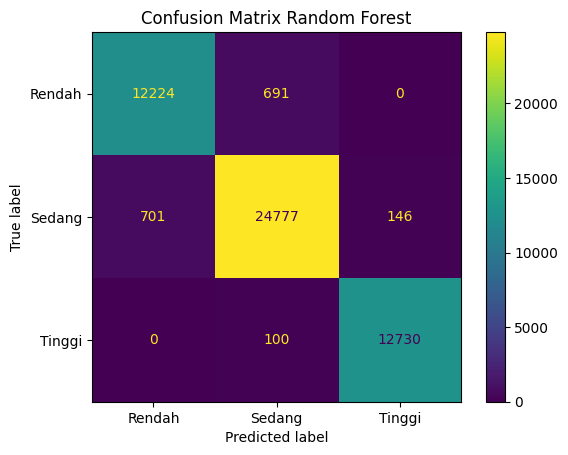

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Rendah', 'Sedang', 'Tinggi']
)

disp.plot()
plt.title("Confusion Matrix Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Menghitung Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm_rf)

Confusion Matrix Random Forest:
[[12224   691     0]
 [  701 24777   146]
 [    0   100 12730]]


### Confusion Matrix Decision Tree

Confusion matrix digunakan untuk melihat jumlah prediksi yang benar dan kesalahan prediksi pada masing-masing kategori konsumsi energi.

In [ ]:
from sklearn.metrics import confusion_matrix

# Menghitung Confusion Matrix Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[12191   724     0]
 [  859 24609   156]
 [    0   156 12674]]


## 11. Perbandingan Model

Perbandingan dilakukan untuk melihat perbedaan akurasi antara model Decision Tree dan Random Forest.

Hasil akurasi:
- Decision Tree: 96,31%
- Random Forest: 96,81%

Selisih akurasi kedua model adalah 0,50 poin persentase.

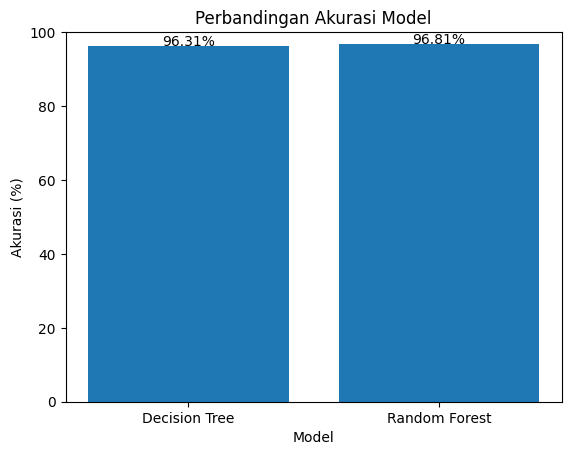

In [ ]:
import matplotlib.pyplot as plt

# Data akurasi
model = ['Decision Tree', 'Random Forest']
akurasi = [akurasi_dt * 100, akurasi_rf * 100]

# Membuat grafik
plt.bar(model, akurasi)

plt.title('Perbandingan Akurasi Model')
plt.xlabel('Model')
plt.ylabel('Akurasi (%)')

# Menampilkan nilai di atas batang
for i, nilai in enumerate(akurasi):
    plt.text(i, nilai + 0.1, f'{nilai:.2f}%', ha='center')

plt.ylim(0, 100)
plt.show()

### Classification Report Random Forest

Classification report digunakan untuk melihat precision, recall, dan F1-score dari model Random Forest pada setiap kategori konsumsi energi.

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report Random Forest:
              precision    recall  f1-score   support

      Rendah       0.95      0.95      0.95     12915
      Sedang       0.97      0.97      0.97     25624
      Tinggi       0.99      0.99      0.99     12830

    accuracy                           0.97     51369
   macro avg       0.97      0.97      0.97     51369
weighted avg       0.97      0.97      0.97     51369



### Tabel Perbandingan Model

Tabel berikut digunakan untuk membandingkan akurasi model Decision Tree dan Random Forest berdasarkan hasil pengujian pada data testing.

In [ ]:
import pandas as pd

# Membuat tabel perbandingan model
hasil_model = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [akurasi_dt, akurasi_rf],
    'Accuracy (%)': [akurasi_dt * 100, akurasi_rf * 100]
})

hasil_model

,Model,Accuracy,Accuracy (%)
0,Decision Tree,0.963110,96.311005
1,Random Forest,0.968113,96.811306


## 12. Prediksi Data Baru

Setelah kedua model dilatih dan dievaluasi, dilakukan pengujian menggunakan satu data baru.

Data baru memiliki nilai:
- Global Reactive Power: 0,10
- Voltage: 240,00
- Global Intensity: 2,50
- Sub Metering 1: 0,00
- Sub Metering 2: 1,00
- Sub Metering 3: 10,00

Data tersebut kemudian diprediksi menggunakan model Decision Tree dan Random Forest.

In [ ]:
# Membuat data baru dengan nama kolom yang sama seperti data training
data_baru = pd.DataFrame([[
    0.10,   # global_reactive_power
    240.00, # voltage
    2.50,   # global_intensity
    0.00,   # sub_metering_1
    1.00,   # sub_metering_2
    10.00   # sub_metering_3
]], columns=X.columns)

# Prediksi menggunakan Decision Tree
prediksi_dt = dt_model.predict(data_baru)

# Prediksi menggunakan Random Forest
prediksi_rf = rf_model.predict(data_baru)

print("Prediksi Decision Tree :", prediksi_dt[0])
print("Prediksi Random Forest :", prediksi_rf[0])

Prediksi Decision Tree : Sedang
Prediksi Random Forest : Sedang


# 13. Kesimpulan

Berdasarkan hasil pengujian, model Decision Tree memperoleh akurasi sebesar 96,31%, sedangkan Random Forest memperoleh akurasi sebesar 96,81%. Kedua model mampu mengklasifikasikan konsumsi energi rumah tangga ke dalam tiga kategori, yaitu Rendah, Sedang, dan Tinggi pada dataset yang digunakan.

Pada pengujian menggunakan data baru, Decision Tree dan Random Forest sama-sama menghasilkan prediksi kategori Sedang. Hasil klasifikasi ini dapat digunakan sebagai informasi pendukung untuk mengevaluasi penggunaan energi dan membantu upaya efisiensi energi yang berkaitan dengan SDG 7.